# Segment Analysis (BFS v0.6 Governance)
This notebook evaluates the BFS v0.5 benchmark model across critical borrower segments to ensure fairness and prevent disproportionate failure rates in vulnerable cohorts.

In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Load Data & Model
data_dir = "../dummtdatasets/cibil_ind"
target_col = "Approved_Flag"

df_test = pd.read_csv(os.path.join(data_dir, "cibil_test.csv"))
df_test.replace(-99999, np.nan, inplace=True)

def map_target(y):
    return y.map({'P1': 0, 'P2': 0, 'P3': 1, 'P4': 1}).fillna(0).astype(int)
y_test = map_target(df_test[target_col])

drop_cols = [
    target_col, "PROSPECTID", "Credit_Score",
    "enq_L3m", "enq_L6m", "enq_L12m", "tot_enq", "time_since_recent_enq",
    "CC_enq", "CC_enq_L6m", "CC_enq_L12m", "PL_enq", "PL_enq_L6m", "PL_enq_L12m",
    "pct_PL_enq_L6m_of_ever", "pct_CC_enq_L6m_of_ever", "pct_PL_enq_L6m_of_L12m", "pct_CC_enq_L6m_of_L12m",
    "Age_Oldest_TL", "Age_Newest_TL",
    "time_since_recent_deliquency", "time_since_first_deliquency",
    "num_std_12mts", "num_std_6mts", "num_std", "num_times_delinquent", "max_delinquency_level",
    "recent_level_of_deliq", "max_recent_level_of_deliq",
    "CC_Flag", "PL_Flag", "HL_Flag", "GL_Flag"
]
X_test = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])

cat_cols = X_test.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    X_test[col] = X_test[col].astype('category')

model_path = os.path.join(data_dir, "xgboost_cibil_calibrated.pkl")
model = joblib.load(model_path)
y_prob = model.predict_proba(X_test)[:, 1]

print("Global AUC:", roc_auc_score(y_test, y_prob))

Global AUC: 0.7926066479564988


,Segment,AUC,N
0,Age < 30,0.772711,2949
1,Age > 45,0.814658,932
2,Thin File (Total_TL < 2),0.813772,2432
3,High Utilization (Top 25%),0.764492,1079


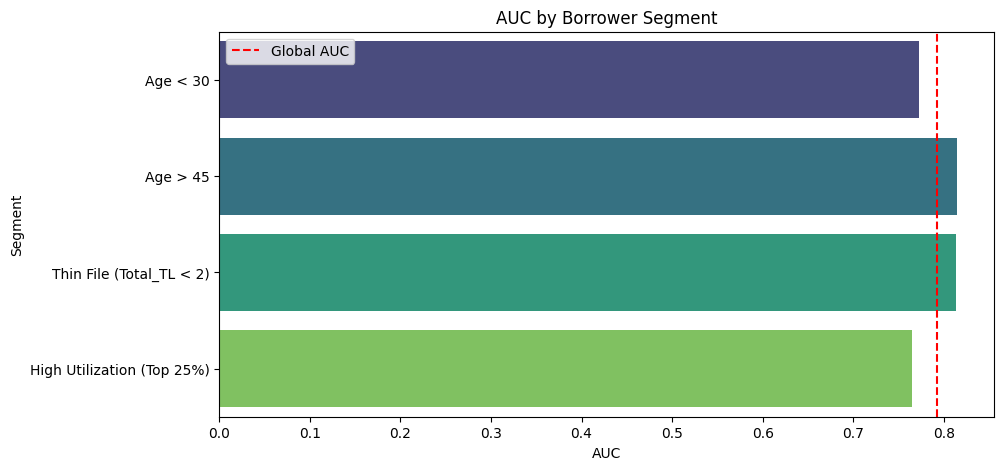

In [4]:
# 2. Define Segments
segments = {
    "Age < 30": df_test['AGE'] < 30,
    "Age > 45": df_test['AGE'] > 45,
    "Thin File (Total_TL < 2)": df_test['Total_TL'] < 2,
    "High Utilization (Top 25%)": df_test['max_unsec_exposure_inPct'] > df_test['max_unsec_exposure_inPct'].quantile(0.75)
}

results = []
for name, mask in segments.items():
    if mask.sum() > 0:
        seg_y = y_test[mask]
        seg_prob = y_prob[mask]
        if len(seg_y.unique()) > 1:
            auc = roc_auc_score(seg_y, seg_prob)
            results.append({'Segment': name, 'AUC': auc, 'N': mask.sum()})
        else:
            results.append({'Segment': name, 'AUC': np.nan, 'N': mask.sum()})

df_res = pd.DataFrame(results)
display(df_res)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_res, x='AUC', y='Segment', palette='viridis')
plt.axvline(roc_auc_score(y_test, y_prob), color='red', linestyle='--', label='Global AUC')
plt.title('AUC by Borrower Segment')
plt.legend()
plt.show()